# Task 1: Load and Visualize the CIFAR-10 Dataset

## Objective
To load the CIFAR-10 dataset, understand its structure, visualize sample images from different classes, and analyze the class distribution.

## Theory
The CIFAR-10 dataset is a benchmark image classification dataset consisting of 60,000 color images of size 32 × 32 pixels belonging to 10 different object classes. It contains 50,000 training images and 10,000 testing images. Before training a Convolutional Neural Network (CNN), it is essential to explore the dataset and verify that all classes are equally represented.

## Steps Performed
- Imported the required libraries.
- Loaded the CIFAR-10 dataset.
- Displayed sample images with their class labels.
- Calculated the number of images in each class.
- Plotted the class distribution.
- Saved all generated figures in PNG and EPS formats (600 dpi).

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2815s 17us/step
CIFAR-10 Dataset Information
Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)
Testing Images Shape  : (10000, 32, 32, 3)
Testing Labels Shape  : (10000, 1)


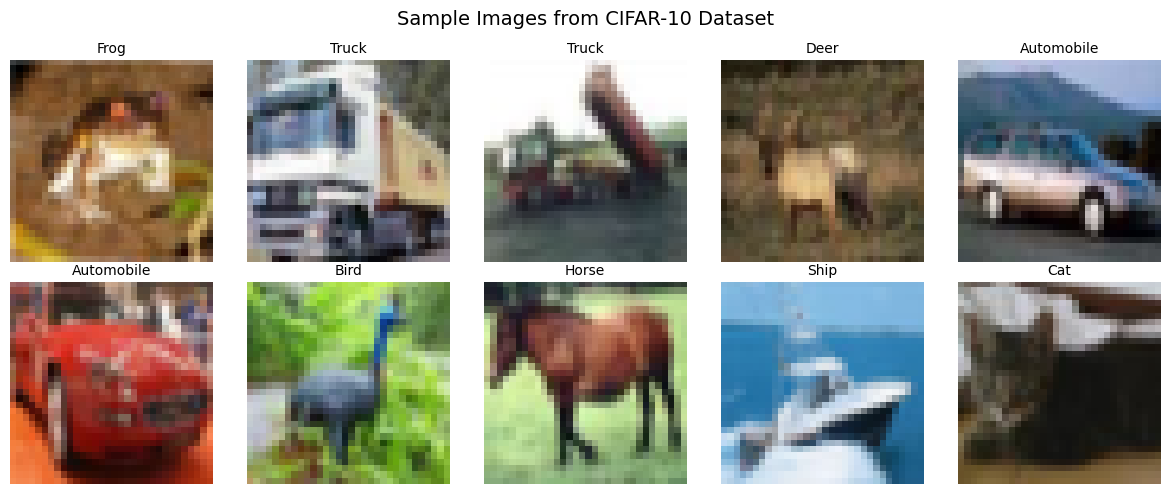

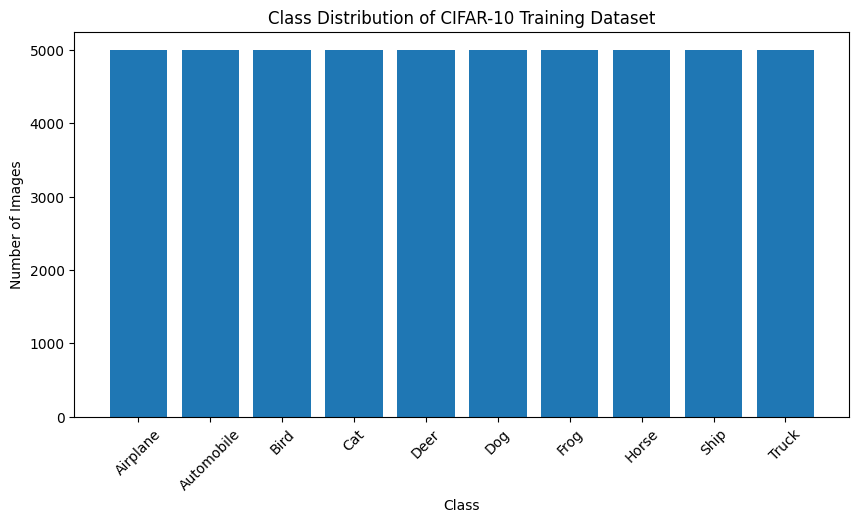


Task 1 Completed Successfully!
Figures saved in folder: CNN_Experiment3_Figures


In [ ]:
# ==========================================================
# TASK 1: Load CIFAR-10 Dataset and Explore the Data
# ==========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Create output folder for figures
output_folder = "CNN_Experiment3_Figures"
os.makedirs(output_folder, exist_ok=True)

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# CIFAR-10 class names
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

# Print dataset dimensions
print("=" * 50)
print("CIFAR-10 Dataset Information")
print("=" * 50)
print(f"Training Images Shape : {x_train.shape}")
print(f"Training Labels Shape : {y_train.shape}")
print(f"Testing Images Shape  : {x_test.shape}")
print(f"Testing Labels Shape  : {y_test.shape}")

# ----------------------------------------------------------
# Display 10 Sample Images
# ----------------------------------------------------------
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Images from CIFAR-10 Dataset", fontsize=14)
plt.tight_layout()

# Save figure
plt.savefig(f"{output_folder}/sample_images.png", dpi=600, bbox_inches="tight")
plt.savefig(f"{output_folder}/sample_images.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

# ----------------------------------------------------------
# Plot Class Distribution
# ----------------------------------------------------------
class_counts = np.bincount(y_train.flatten())

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)

plt.title("Class Distribution of CIFAR-10 Training Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

# Save figure
plt.savefig(f"{output_folder}/class_distribution.png", dpi=600, bbox_inches="tight")
plt.savefig(f"{output_folder}/class_distribution.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

print("\nTask 1 Completed Successfully!")
print(f"Figures saved in folder: {output_folder}")



# Task 2: Convolution Layer Implementation and Kernel Comparison

## Objective
To implement a convolution layer and compare the effect of different kernel sizes on the extracted feature maps.

## Theory
A convolution layer extracts important spatial features such as edges, textures, and patterns from an image using learnable filters called kernels. The kernel size determines the receptive field of the filter. Smaller kernels preserve finer details, whereas larger kernels capture broader contextual information but reduce the feature map dimensions.

## Steps Performed
- Selected a sample image from the dataset.
- Applied convolution using kernel sizes of 3×3, 5×5, and 7×7.
- Generated feature maps for each kernel.
- Compared the output feature map dimensions.
- Saved all feature map visualizations.

Kernel Size : 3 x 3
Output Feature Map Shape : (1, 30, 30, 8)


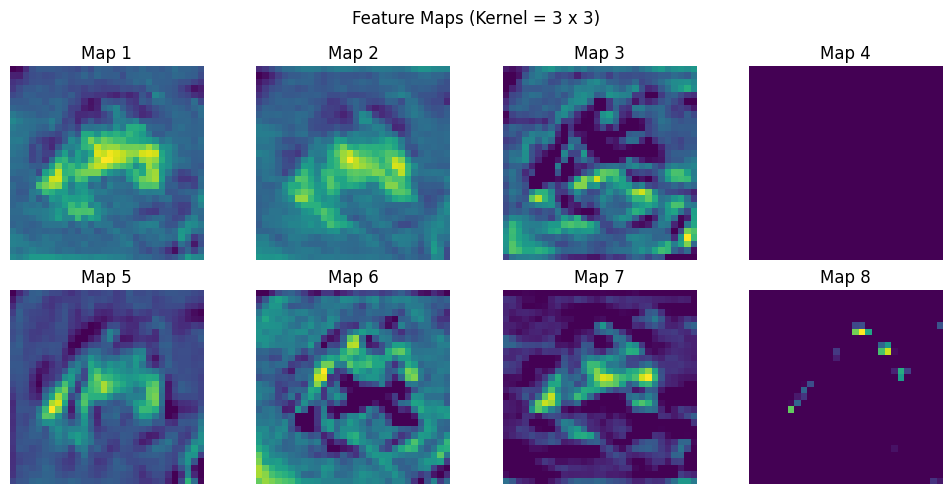

Kernel Size : 5 x 5
Output Feature Map Shape : (1, 28, 28, 8)


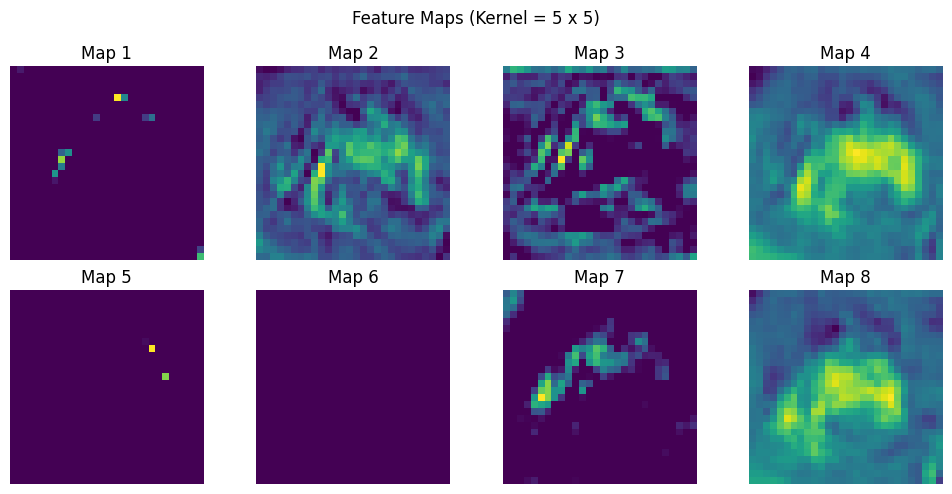

Kernel Size : 7 x 7
Output Feature Map Shape : (1, 26, 26, 8)


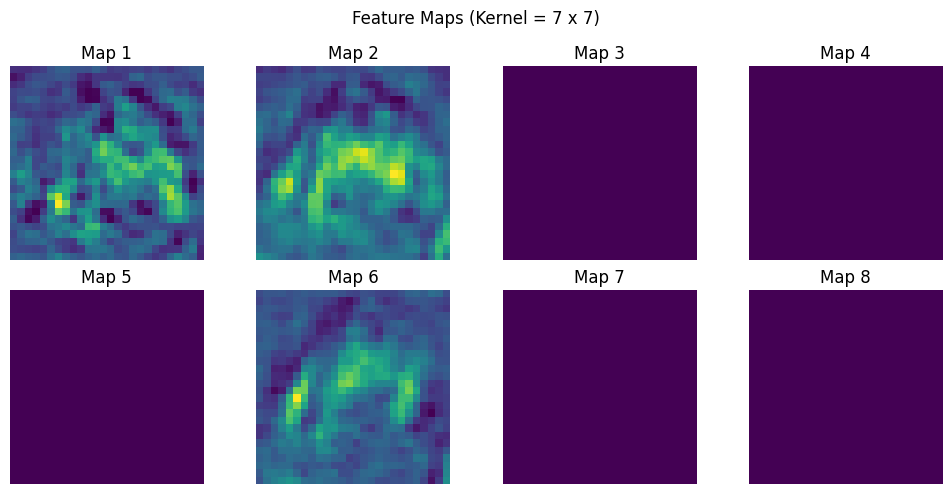


Task 2 Completed Successfully!


In [ ]:
# ==========================================================
# TASK 2: Implement Convolution Layer
# Compare Kernel Sizes: 3x3, 5x5, 7x7
# ==========================================================

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D

# Select one sample image
sample = x_train[0:1]

kernel_sizes = [3, 5, 7]

for k in kernel_sizes:

    # Create convolution layer
    conv_layer = Conv2D(
        filters=8,
        kernel_size=(k, k),
        strides=(1, 1),
        padding='valid',
        activation='relu'
    )

    # Apply convolution
    feature_maps = conv_layer(sample)

    print("=" * 50)
    print(f"Kernel Size : {k} x {k}")
    print(f"Output Feature Map Shape : {feature_maps.shape}")

    # Display first 8 feature maps
    fig, axes = plt.subplots(2, 4, figsize=(10, 5))

    for i, ax in enumerate(axes.flat):
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
        ax.set_title(f"Map {i+1}")
        ax.axis('off')

    plt.suptitle(f"Feature Maps (Kernel = {k} x {k})")
    plt.tight_layout()

    # Save figures
    plt.savefig(f"{output_folder}/feature_maps_kernel_{k}.png",
                dpi=600, bbox_inches="tight")
    plt.savefig(f"{output_folder}/feature_maps_kernel_{k}.eps",
                format="eps", dpi=600, bbox_inches="tight")

    plt.show()

print("\nTask 2 Completed Successfully!")

# Task 3: Effect of Stride and Padding

## Objective
To study how stride and padding influence the output feature map dimensions after convolution.

## Theory
Stride determines the number of pixels the convolution filter moves during each operation. Padding controls whether additional pixels are added around the image boundaries before convolution. Different combinations of stride and padding directly affect the size of the output feature maps and the amount of spatial information retained.

## Steps Performed
- Applied convolution with different stride values.
- Compared SAME and VALID padding techniques.
- Observed the resulting feature map sizes.
- Visualized the generated feature maps.

Stride  : 1
Padding : SAME
Output Shape : (1, 32, 32, 8)


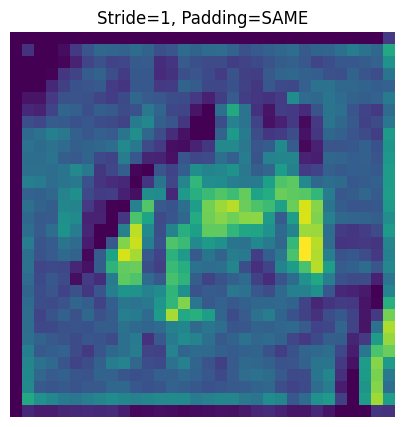

Stride  : 1
Padding : VALID
Output Shape : (1, 30, 30, 8)


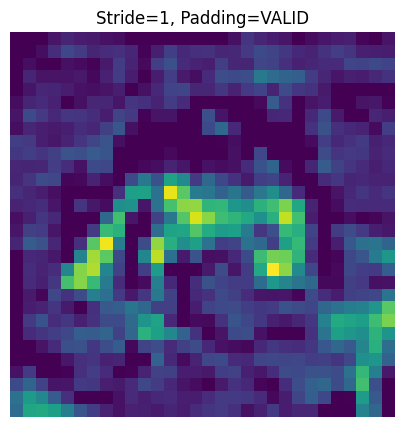

Stride  : 2
Padding : SAME
Output Shape : (1, 16, 16, 8)


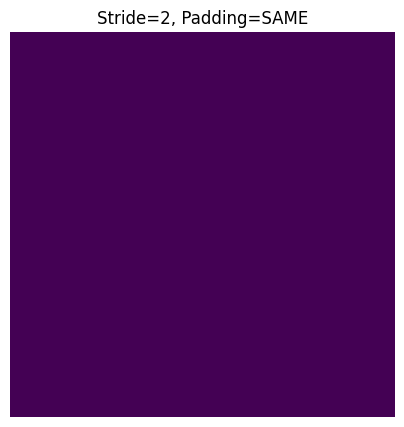

Stride  : 2
Padding : VALID
Output Shape : (1, 15, 15, 8)


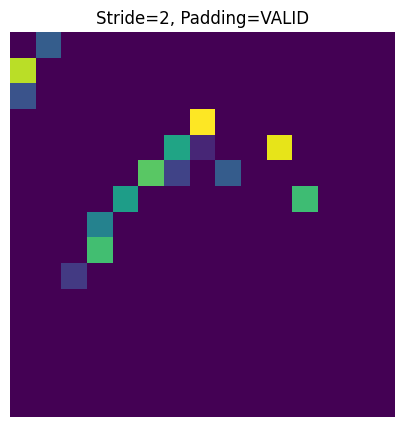


Task 3 Completed Successfully!


In [ ]:
# ==========================================================
# TASK 3: Study Hyperparameters
# Compare:
#   • Stride = 1
#   • Stride = 2
#   • Padding = Same
#   • Padding = Valid
# ==========================================================

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D

# Use one sample image
sample = x_train[0:1]

# Configuration: (Stride, Padding)
configs = [
    (1, "same"),
    (1, "valid"),
    (2, "same"),
    (2, "valid")
]

for stride, padding in configs:

    conv = Conv2D(
        filters=8,
        kernel_size=(3, 3),
        strides=(stride, stride),
        padding=padding,
        activation="relu"
    )

    feature_maps = conv(sample)

    print("=" * 60)
    print(f"Stride  : {stride}")
    print(f"Padding : {padding.upper()}")
    print(f"Output Shape : {feature_maps.shape}")

    plt.figure(figsize=(5,5))
    plt.imshow(feature_maps[0, :, :, 0], cmap="viridis")
    plt.title(f"Stride={stride}, Padding={padding.upper()}")
    plt.axis("off")

    # Save figure
    filename = f"stride_{stride}_padding_{padding}"
    plt.savefig(f"{output_folder}/{filename}.png",
                dpi=600, bbox_inches="tight")
    plt.savefig(f"{output_folder}/{filename}.eps",
                format="eps",
                dpi=600,
                bbox_inches="tight")

    plt.show()

print("\nTask 3 Completed Successfully!")

# Task 4: Feature Map Visualization

## Objective
To visualize the feature maps produced by the first convolution layer of the CNN.

## Theory
Each convolution filter learns a unique visual pattern from the input image. Feature maps illustrate how different filters respond to various image regions, highlighting edges, textures, shapes, and other significant visual characteristics. Visualizing these maps provides insight into the feature extraction capability of CNNs.

## Steps Performed
- Built a CNN containing a single convolution layer.
- Passed a sample image through the network.
- Extracted the feature maps generated by the first convolution layer.
- Displayed and saved the first eight feature maps.

Feature Map Shape: (1, 32, 32, 8)


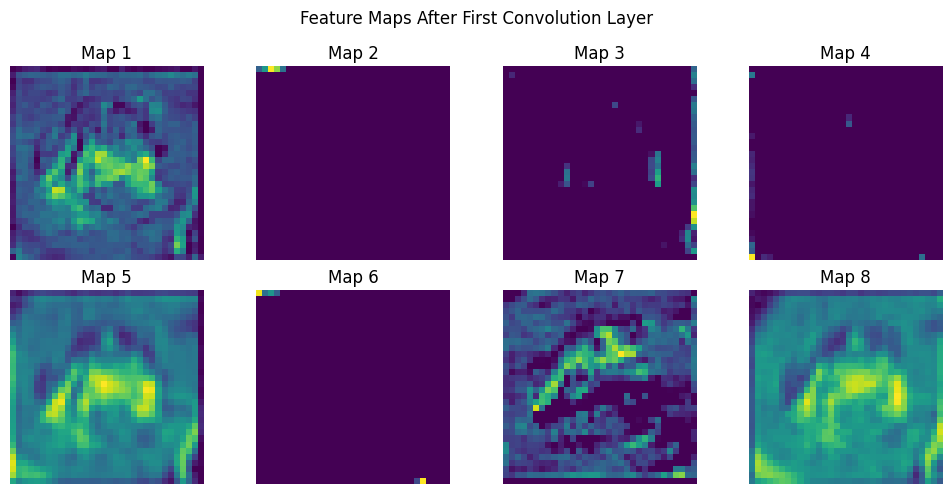


Task 4 Completed Successfully!
Feature Map Size : 32 x 32
Number of Feature Maps : 8


In [ ]:
# ==========================================================
# TASK 4: Visualize Feature Maps After First Convolution Layer
# ==========================================================

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D
from tensorflow.keras.models import Model

# ----------------------------------------------------------
# Build a simple model with one convolution layer
# ----------------------------------------------------------
inputs = Input(shape=(32, 32, 3))

x = Conv2D(
    filters=8,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(inputs)

feature_model = Model(inputs=inputs, outputs=x)

# ----------------------------------------------------------
# Use one sample image
# ----------------------------------------------------------
sample = x_train[0:1]

# Generate feature maps
feature_maps = feature_model.predict(sample, verbose=0)

print("=" * 50)
print("Feature Map Shape:", feature_maps.shape)

# ----------------------------------------------------------
# Display first 8 feature maps
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, :, :, i], cmap="viridis")
    ax.set_title(f"Map {i+1}")
    ax.axis("off")

plt.suptitle("Feature Maps After First Convolution Layer")
plt.tight_layout()

# Save figures
plt.savefig(f"{output_folder}/first_conv_feature_maps.png",
            dpi=600, bbox_inches="tight")
plt.savefig(f"{output_folder}/first_conv_feature_maps.eps",
            format="eps", dpi=600, bbox_inches="tight")

plt.show()

print("\nTask 4 Completed Successfully!")
print(f"Feature Map Size : {feature_maps.shape[1]} x {feature_maps.shape[2]}")
print(f"Number of Feature Maps : {feature_maps.shape[3]}")

# Task 5: Comparison of Max Pooling and Average Pooling

## Objective
To compare the performance of Max Pooling and Average Pooling layers in a CNN.

## Theory
Pooling layers reduce the spatial dimensions of feature maps, thereby lowering computational complexity and helping prevent overfitting. Max Pooling selects the maximum value within each pooling window, preserving the most prominent features, whereas Average Pooling computes the average value, producing smoother feature representations.

## Steps Performed
- Built two CNN models with identical architectures.
- Used Max Pooling in the first model.
- Used Average Pooling in the second model.
- Compared output dimensions and classification accuracy.
- Plotted and saved the comparison results.

Output Shape After Pooling
Max Pooling Output Shape     : (None, 16, 16, 16)
Average Pooling Output Shape : (None, 16, 16, 16)

Training CNN with Max Pooling...
Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4538 - loss: 1.5590 - val_accuracy: 0.5179 - val_loss: 1.3865
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5542 - loss: 1.2860 - val_accuracy: 0.5359 - val_loss: 1.3326
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5832 - loss: 1.1987 - val_accuracy: 0.5695 - val_loss: 1.2408
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6050 - loss: 1.1426 - val_accuracy: 0.5830 - val_loss: 1.2285
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6171 - loss: 1.1018 - val_accuracy: 0.5926 - val_loss: 1.1847

Training CNN with Average Pooling...
Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4242 - loss: 1.6436 - val_accuracy: 0.4869 - val_loss: 1.4771
Epoch 2/5
1250/1250 ━━━━━━━

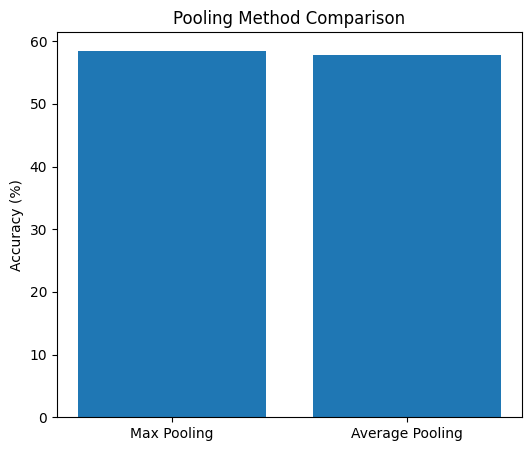


Task 5 Completed Successfully!


In [ ]:
# ==========================================================
# TASK 5: Compare Max Pooling vs Average Pooling
# ==========================================================

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     AveragePooling2D, Flatten, Dense)

# ----------------------------------------------------------
# Function to create CNN model
# ----------------------------------------------------------
def create_model(pooling_type="max"):

    model = Sequential()

    model.add(Input(shape=(32, 32, 3)))

    model.add(Conv2D(16, (3,3), activation='relu', padding='same'))

    if pooling_type == "max":
        model.add(MaxPooling2D(pool_size=(2,2)))
    else:
        model.add(AveragePooling2D(pool_size=(2,2)))

    model.add(Flatten())
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ----------------------------------------------------------
# Create Models
# ----------------------------------------------------------
max_model = create_model("max")
avg_model = create_model("avg")

# ----------------------------------------------------------
# Output Feature Map Sizes
# ----------------------------------------------------------
print("="*55)
print("Output Shape After Pooling")
print("="*55)

print("Max Pooling Output Shape     :", max_model.layers[1].output.shape)
print("Average Pooling Output Shape :", avg_model.layers[1].output.shape)

# ----------------------------------------------------------
# Train Models
# ----------------------------------------------------------
print("\nTraining CNN with Max Pooling...")
history_max = max_model.fit(
    x_train,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nTraining CNN with Average Pooling...")
history_avg = avg_model.fit(
    x_train,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ----------------------------------------------------------
# Evaluate Models
# ----------------------------------------------------------
max_loss, max_acc = max_model.evaluate(x_test, y_test_cat, verbose=0)
avg_loss, avg_acc = avg_model.evaluate(x_test, y_test_cat, verbose=0)

print("\n" + "="*55)
print("Test Accuracy Comparison")
print("="*55)
print(f"Max Pooling Accuracy     : {max_acc*100:.2f}%")
print(f"Average Pooling Accuracy : {avg_acc*100:.2f}%")

# ----------------------------------------------------------
# Accuracy Comparison Plot
# ----------------------------------------------------------
plt.figure(figsize=(6,5))

plt.bar(
    ["Max Pooling", "Average Pooling"],
    [max_acc*100, avg_acc*100]
)

plt.ylabel("Accuracy (%)")
plt.title("Pooling Method Comparison")

plt.savefig(f"{output_folder}/pooling_accuracy_comparison.png",
            dpi=600,
            bbox_inches="tight")

plt.savefig(f"{output_folder}/pooling_accuracy_comparison.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

print("\nTask 5 Completed Successfully!")

# Task 6: CNN Model Construction and Training

## Objective
To construct, train, and validate a Convolutional Neural Network (CNN) for image classification using the CIFAR-10 dataset.

## Theory
A Convolutional Neural Network automatically learns hierarchical image features through convolution and pooling operations. During training, the network updates its weights using the Adam optimizer to minimize the categorical cross-entropy loss. Training and validation accuracy/loss curves help evaluate the learning process and detect overfitting or underfitting.

## CNN Architecture

Input → Convolution → ReLU → Max Pooling → Convolution → ReLU → Max Pooling → Flatten → Dense → Softmax

## Steps Performed
- Constructed the CNN architecture.
- Compiled the model using the Adam optimizer.
- Trained the model for 20 epochs with a batch size of 32.
- Recorded training and validation accuracy.
- Recorded training and validation loss.
- Saved all performance plots.

CNN Model Summary


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4984 - loss: 1.4035 - val_accuracy: 0.5874 - val_loss: 1.1669
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6422 - loss: 1.0248 - val_accuracy: 0.6492 - val_loss: 1.0084
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6882 - loss: 0.8878 - val_accuracy: 0.6899 - val_loss: 0.9146
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7273 - loss: 0.7803 - val_accuracy: 0.6978 - val_loss: 0.8891
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7541 - loss: 0.6964 - val_accuracy: 0.6933 - val_loss: 0.9020
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7871 - loss: 0.6113 - val_accuracy: 0.6987 - val_loss: 0.9338
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8141 - loss: 0.5326 - val_accuracy: 0.7058 - val_loss: 0.9125
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8399 - loss: 0.4574 -

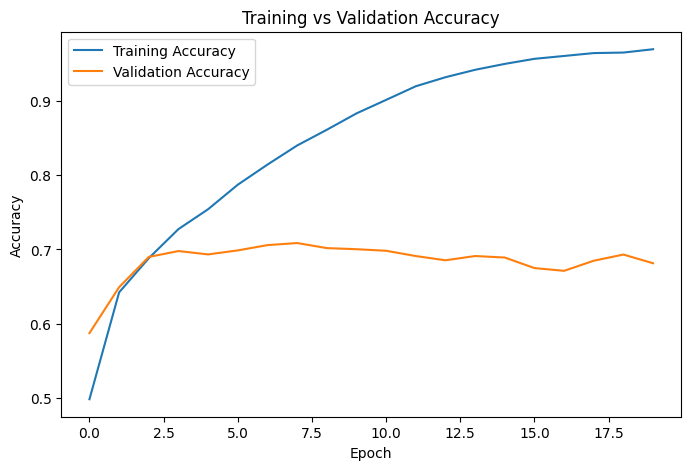

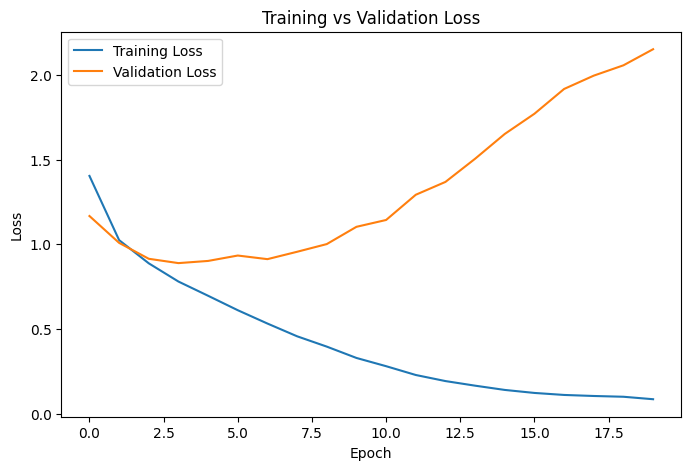


Task 6 Completed Successfully!


In [ ]:
# ==========================================================
# TASK 6: CNN Model Construction and Training
# Architecture:
# Input → Conv → ReLU → MaxPool → Conv → ReLU → MaxPool
# → Flatten → Dense → Softmax
# ==========================================================

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

# ----------------------------------------------------------
# Build CNN Model
# ----------------------------------------------------------
cnn_model = Sequential([

    Input(shape=(32,32,3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')

])

# ----------------------------------------------------------
# Compile Model
# ----------------------------------------------------------
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("="*60)
print("CNN Model Summary")
print("="*60)

cnn_model.summary()

# ----------------------------------------------------------
# Train Model
# ----------------------------------------------------------
history = cnn_model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# ----------------------------------------------------------
# Plot Training & Validation Accuracy
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(f"{output_folder}/training_validation_accuracy.png",
            dpi=600,
            bbox_inches='tight')

plt.savefig(f"{output_folder}/training_validation_accuracy.eps",
            format='eps',
            dpi=600,
            bbox_inches='tight')

plt.show()

# ----------------------------------------------------------
# Plot Training & Validation Loss
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(f"{output_folder}/training_validation_loss.png",
            dpi=600,
            bbox_inches='tight')

plt.savefig(f"{output_folder}/training_validation_loss.eps",
            format='eps',
            dpi=600,
            bbox_inches='tight')

plt.show()

print("\nTask 6 Completed Successfully!")

# Task 7: CNN Model Evaluation

## Objective
To evaluate the performance of the trained CNN model on the test dataset using standard classification metrics.

## Theory
After training, the CNN is evaluated on previously unseen test images to measure its generalization capability. Evaluation metrics such as Accuracy, Precision, Recall, and F1-score provide quantitative measures of classification performance, while the Confusion Matrix and Classification Report offer class-wise insights into correct predictions and misclassifications.

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Classification Report

## Steps Performed
- Generated predictions for the test dataset.
- Calculated Accuracy, Precision, Recall, and F1-score.
- Generated the Classification Report.
- Constructed the Confusion Matrix.
- Saved the Confusion Matrix in PNG and EPS formats.

CNN MODEL EVALUATION
Accuracy  : 0.6828 (68.28%)
Precision : 0.6876
Recall    : 0.6828
F1-Score  : 0.6834

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Airplane       0.69      0.77      0.73      1000
  Automobile       0.81      0.83      0.82      1000
        Bird       0.55      0.56      0.56      1000
         Cat       0.47      0.54      0.50      1000
        Deer       0.69      0.55      0.61      1000
         Dog       0.58      0.58      0.58      1000
        Frog       0.79      0.71      0.74      1000
       Horse       0.77      0.68      0.72      1000
        Ship       0.79      0.80      0.80      1000
       Truck       0.75      0.81      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



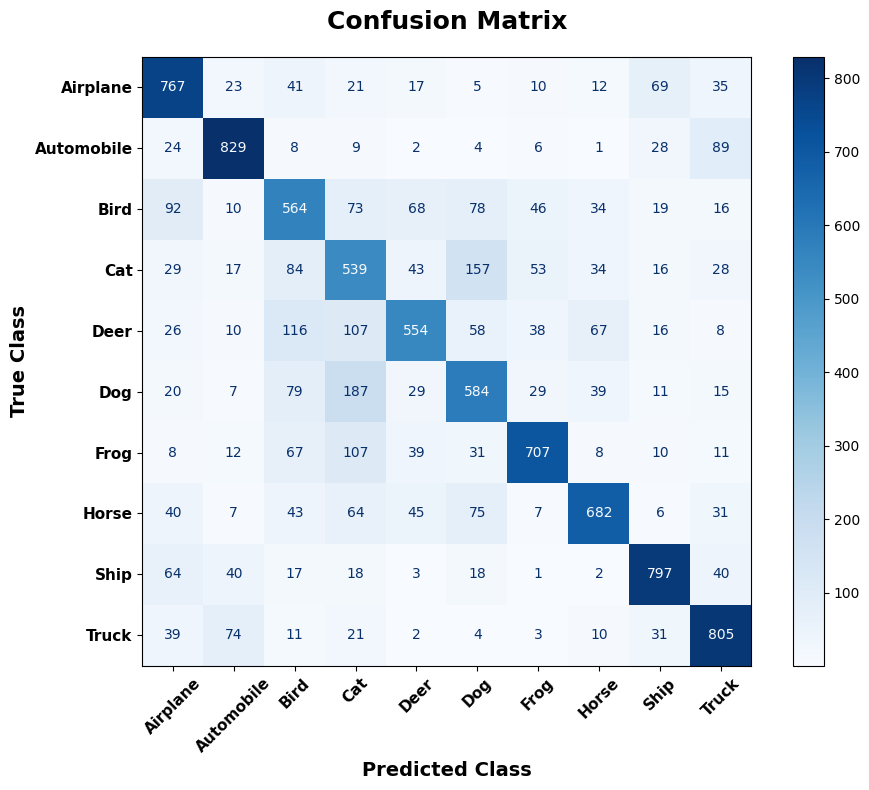


FINAL TEST RESULTS
Test Accuracy  : 68.28%
Precision      : 0.6876
Recall         : 0.6828
F1-Score       : 0.6834

Task 7 Completed Successfully!
Confusion Matrix saved in: CNN_Experiment3_Figures


In [ ]:
# ==========================================================
# TASK 7: Model Evaluation
# Evaluate:
# • Accuracy
# • Precision
# • Recall
# • F1-score
# • Confusion Matrix
# • Classification Report
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ----------------------------------------------------------
# Predict on Test Dataset
# ----------------------------------------------------------
y_pred_prob = cnn_model.predict(x_test, verbose=0)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# ----------------------------------------------------------
# Evaluation Metrics
# ----------------------------------------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("="*70)
print("CNN MODEL EVALUATION")
print("="*70)

print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    colorbar=True,
    xticks_rotation=45,
    ax=ax
)

# -------------------------------
# Beautify Plot
# -------------------------------
ax.set_title(
    "Confusion Matrix",
    fontsize=18,
    fontweight='bold',
    pad=20
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    "True Class",
    fontsize=14,
    fontweight='bold'
)

# Bold tick labels
for label in ax.get_xticklabels():
    label.set_fontsize(11)
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontsize(11)
    label.set_fontweight('bold')

plt.tight_layout()

# ----------------------------------------------------------
# Save Figures
# ----------------------------------------------------------
plt.savefig(
    f"{output_folder}/confusion_matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    f"{output_folder}/confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------
# Final Summary
# ----------------------------------------------------------
print("\n" + "="*70)
print("FINAL TEST RESULTS")
print("="*70)
print(f"Test Accuracy  : {accuracy*100:.2f}%")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")

print("\nTask 7 Completed Successfully!")
print(f"Confusion Matrix saved in: {output_folder}")